<img src="Images/Syriatel_logo.svg.png" alt="SyriaTel Logo" width="500">

# Predicting Customer Churn at SyriaTel
## Machine Learning Modeling

Flatiron School: Phase 3 Project
* **Author**: Mohammad Abou-Ghazala
* **Instructor**: Mark Barbour

# I. Business Understanding

Our company, SyriaTel, is a telecommunications company based and operating in Syria, and is looking to better understand the patterns shown by customers who are likely to switch to another telecom company, referred to as "customer churn." While it will be impossible to predict with 100% confidence who will or won't churn, not least of which due to a variety of confounding factors relating to more than 13 years of civil war and the recent collapse of the ruling regime, we can search for predictable patterns within customer data that would highlight potential warning signs that a SyriaTel customer may be on the verge of churning. 

The essential questions for us to address are:
1. What factors indicate that a customer may churn? Are there any predictable patterns?
2. What can SyriaTel do to minimize the likelihood of churning?

# II. Data Understanding

To answer these questions, we will treat the problem as one of binary classification and construct a predictive model. In order to maximize analytical efficacy, we will utilize several different machine learning models for classification and determine which model is more useful by comparing scores assessing the models' performance. 

### False Negatives and False Positives
- A positive prediction entails that the customer **is** likely to churn.
- A negative prediction indicates a customer **is not** likely to churn.

While we must be wary of both False Positives (FPs) and False Negatives (FNs) in our predictive models, since our purpose is to minimize customer churn we must prioritize minimizing rates of False Negatives, as falsely predicting a customer is unlikely to churn means that SyriaTel will fail to act to prevent this churn, whereas a False Positive will cost the company less in the long run as the customer will not churn.

### Model Scoring
For this reason, we will prioritize comparing the following in evaluating the various models:
1. `Recall` score, also known as "sensitivity", which essentially evaluates how successful our models were in actually predicting Positives. In other words, **a high Recall score means fewer False Negatives.**
2. `ROC-AUC` [Receiver Operator Characteristic - Area Under the Curve] score, which essentially provides a scaled value that determines how effective our models were in distinguishing between Positive and Negative outcomes.

### Dataset: Features & Target
The dataset we will be working with, which can be found [here](https://www.kaggle.com/datasets/becksddf/churn-in-telecoms-dataset/discussion?sort=hotness), is pulled from Kaggle.

The dataset contains records for 3,333 customers, and 21 columns with a variety of information about the customer.

Our **Target** column will be `churn`, which contains boolean values of whether the customer churned or not. The dataset indicates that about 14% of customers did churn, while 86% did not churn.

This leaves 20 columns to be considered as **Features**. While the dataset includes a number of Categorial Variables (object datatypes), the majority of columns are Discrete Numeric (integer or float datatypes). Luckily, the dataset contains no null values.

## II.a. Data Preparation

First, we need to import the libraries required for this project, and inspect the dataset.

In [1]:
# importing necessary libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve, get_scorer, classification_report

from imblearn.over_sampling import SMOTE


In [2]:
# loading in the dataset
df = pd.read_csv("data/SyriaTel_Data.csv")
df.head()

,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


### Metadata for the Columns, pulled from Kaggle

`state`: The state of the customer.\
`account length`: The length of the account in days or months.\
`area code`: The area code of the customer's phone number.\
`phone number`: The phone number of the customer.\
`international plan`: Whether the customer has an international plan or not.\
`voice mail plan`: Whether the customer has a voicemail plan or not.\
`number vmail messages`: The number of voicemail messages the customer has.\
`total day minutes`: Total minutes of day calls.\
`total day calls`: Total number of day calls.\
`total day charge`: Total charge for the day calls.\
`total eve minutes`: Total minutes of evening calls.\
`total eve calls`: Total number of evening calls.\
`total eve charge`: Total charge for the evening calls.\
`total night minutes`: Total minutes of night calls.\
`total night calls`: Total number of night calls.\
`total night charge`: Total charge for the night calls.\
`total intl minutes`: Total minutes of international calls.\
`total intl calls`: Total number of international calls.\
`total intl charge`: Total charge for the international calls.\
`customer service calls`: Number of times the customer called customer service.\
`churn`: Whether the customer churned or not (True/False).

In [3]:
# Inspecting the number of customers (rows) and the number of features (columns)
print(f'Rows, Columns: {df.shape}')
print()
print(f'Columns: {df.columns}')
print()
print(df.info())

Rows, Columns: (3333, 21)

Columns: Index(['state', 'account length', 'area code', 'phone number',
       'international plan', 'voice mail plan', 'number vmail messages',
       'total day minutes', 'total day calls', 'total day charge',
       'total eve minutes', 'total eve calls', 'total eve charge',
       'total night minutes', 'total night calls', 'total night charge',
       'total intl minutes', 'total intl calls', 'total intl charge',
       'customer service calls', 'churn'],
      dtype='object')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   state                   3333 non-null   object 
 1   account length          3333 non-null   int64  
 2   area code               3333 non-null   int64  
 3   phone number            3333 non-null   object 
 4   international plan      3333 non-null   object 
 5   vo

In [4]:
# Listing the Categorical Variables
categorical_columns = df.select_dtypes(include=['object']).columns
print(f"Categorical Columns: {categorical_columns}")

Categorical Columns: Index(['state', 'phone number', 'international plan', 'voice mail plan'], dtype='object')


While `international plan` or `voice mail plan` certainly would be of us to our analysis as they indicate which services the customers subscribe to, the `state` and `phone number` of each customer are probably far less useful to our analysis.

#### Are there any null values we need to be concerned about?

In [5]:
df.isna().sum()

state                     0
account length            0
area code                 0
phone number              0
international plan        0
voice mail plan           0
number vmail messages     0
total day minutes         0
total day calls           0
total day charge          0
total eve minutes         0
total eve calls           0
total eve charge          0
total night minutes       0
total night calls         0
total night charge        0
total intl minutes        0
total intl calls          0
total intl charge         0
customer service calls    0
churn                     0
dtype: int64

#### Is there an imbalance in the Target variable?

In [6]:
# Looking at how many records indicate customer churning vs. no churning
print(df.churn.value_counts())
print()
print(df.churn.value_counts(normalize=True))

churn
False    2850
True      483
Name: count, dtype: int64

churn
False    0.855086
True     0.144914
Name: proportion, dtype: float64


It seems there is heavy imbalance in the `churn` column. If needed, we can try to counter this imbalance using `SMOTE` (synthetic minority oversampling) which would deal with class imbalances by oversampling the minority class.

#### Adjusting the Dataset: Dropping Columns and Changing Datatypes

In [7]:
# Copying the dataframe
df_clean = df.copy()

# Changing "yes/no" inputs with "1/0" numeric inputs
df_clean['voice mail plan'] = df_clean['voice mail plan'].replace({'yes': 1, 'no': 0})
df_clean['international plan'] = df_clean['international plan'].replace({'yes': 1, 'no': 0})

# Dropping unnecessary columns
df_clean = df_clean.drop(['state', 'phone number'], axis=1)

df_clean.head()

,account length,area code,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,128,415,0,1,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,107,415,0,1,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,137,415,0,0,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,84,408,1,0,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,75,415,1,0,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


### Assigning and Splitting the Variables

In [8]:
X = df_clean.copy().drop('churn', axis=1)
y = df_clean['churn'].astype(int)

# Splitting the X and y into training, validation, and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, random_state=42)

### Rebalancing  Classes

Considering the moderate imbalance in the Target classes noted above (86% Negative, 14% Positive), we will try to rebalance those classes by synthetically oversampling the minority class (Negatives) using `SMOTE`.

In [9]:
smote = SMOTE(random_state=42, sampling_strategy=0.3)

# Only rebalancing the training data
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [10]:
# Checking the rebalanced classes

y_train_resampled.value_counts(normalize=True)

churn
0    0.769377
1    0.230623
Name: proportion, dtype: float64

### Scaling the Data

In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)
X_val_scaled = scaler.transform(X_val)

# Turning the scaled arrays back into Dataframes
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train_resampled.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X.columns, index=X_val.index)

In [12]:
X_test_scaled.head()

,account length,area code,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls
438,0.322656,1.724956,-0.313325,-0.565819,-0.555496,-0.521849,-0.389968,-0.521901,2.540295,0.296455,2.540035,-0.258051,1.195316,-0.259368,1.184688,-0.581566,1.190717,-0.428156
2674,-0.855508,-0.521826,-0.313325,-0.565819,-0.555496,-1.329540,0.804502,-1.329283,0.298458,1.200653,0.298644,-0.278035,2.137090,-0.277132,0.928718,0.670259,0.933387,-1.157825
1345,-0.061528,-0.521826,-0.313325,-0.565819,-0.555496,-3.249345,-5.018539,-3.249403,-0.846226,1.502053,-0.845351,-0.703693,-0.635910,-0.703463,-1.265311,-1.416115,-1.260687,1.760851
1957,1.193473,-0.687378,-0.313325,-0.565819,-0.555496,0.495243,-1.086742,0.495608,0.035062,-0.457044,0.035362,-0.921518,0.672109,-0.921069,-0.022028,-0.998840,-0.028213,-0.428156
2148,-0.112752,-0.687378,-0.313325,-0.565819,-0.555496,-0.715413,0.057958,-0.715465,0.443029,-1.361242,0.443099,0.507333,-0.478948,0.508914,-0.095162,1.087534,-0.095932,-0.428156


# III. Exploratory Data Analysis

## Modeling

Since we want to compare the performance of a few models, we'll need to create a function capable of determining the ROC-AUC and Recall scores and produces a legible dataframe for us to easily read. 

This function will calculate those two metrics through the training data, as well as through cross-validation of five subsets. By comparing the scores of these two sets, we can further assess degrees of overfitting or underfitting. 

We will also want to use this function on the test set eventually, in which case there will be no need for cross-validation and the `cv` parameter can be set to False.

In [13]:
def model_metric_results(estimator, X, y, metrics=['roc_auc', 'recall'], 
                         cv=True, k=5):
    train_scores_list = []
    cv_scores_list = []

    for m in metrics:
        scorer = get_scorer(m)
        train_score = scorer(estimator, X, y)
        train_scores_list.append(train_score)

    if cv:
        cv_results = cross_validate(estimator, X, y, cv=k, scoring=metrics)
        for m in metrics:
            cv_mean = np.mean(cv_results['test_' + m])
            cv_scores_list.append(cv_mean)
        df = pd.DataFrame(zip(train_scores_list, cv_scores_list), 
                          columns=['Training_Score', 'Mean_CV_Score'], 
                          index=metrics)
        return df
    else:
        df = pd.DataFrame(data=train_scores_list, 
                          columns=['Score'], 
                          index=metrics)
        return df

In [14]:
# Creating a function to store model results for easier comparison

models_results = {
    'models' : {},
    'results' : {}
}

def store_model_results(name, model, results, dict=models_results):
    dict['models'][name] = model
    dict['results'][name] = results

### Now we can run vanilla models on the scaled and resampled training sets and compare their performance.

#### Logistic Regression

In [15]:
logreg = LogisticRegression(random_state=42)

logreg.fit(X_train_scaled, y_train_resampled)

logreg_results = model_metric_results(logreg, 
                                      X_train_scaled, 
                                      y_train_resampled)

In [16]:
rfc = RandomForestClassifier(random_state=42)

rfc.fit(X_train_scaled, y_train_resampled)

rfc_results = model_metric_results(rfc, 
                                   X_train_scaled, 
                                   y_train_resampled)

In [17]:
adaboost = AdaBoostClassifier(random_state=42)

adaboost.fit(X_train_scaled, y_train_resampled)

adaboost_results = model_metric_results(adaboost, 
                                        X_train_scaled, 
                                        y_train_resampled)

In [18]:
# Storing the results in our model_results dictionary for comparison

store_model_results('logreg', logreg, logreg_results)
store_model_results('rfc', rfc, rfc_results)
store_model_results('adaboost', adaboost, adaboost_results)

In [19]:
# Using for lop to display results for easier comparison

for model, results in models_results['results'].items():
    print(f' Results for {model} model')
    display(results)


 Results for logreg model


,Training_Score,Mean_CV_Score
roc_auc,0.821955,0.808606
recall,0.367010,0.334021


 Results for rfc model


,Training_Score,Mean_CV_Score
roc_auc,1.0,0.945418
recall,1.0,0.746392


 Results for adaboost model


,Training_Score,Mean_CV_Score
roc_auc,0.893108,0.856306
recall,0.513402,0.463918


<div class="alert alert-block alert-info">

**Observation:** The `rfc` model performed best overall, with perfect ROC_AUC and Recall scores for the training sets and very high respective scores for the cross-validation sets.

This indicates a degree of overfitting, however the high scores for the cross-validation sets indicate the model still performs well on unseen data.

Though a 75% Recall score is not bad, we will try to tune the parameters of the chosen model to see if we can optimize its performance even more.

In [89]:
rfc_metrics = model_metric_results(rfc, X_test_scaled, y_test, metrics=['roc_auc', 'recall', 'precision', 'f1', 'accuracy'], cv=False)

print('RTC Resampled Results')
display(rtc_resampled_metrics)

RTC Resampled Results


,Score
roc_auc,0.929427
recall,0.768000
precision,0.941176
f1,0.845815
accuracy,0.958034


Though all the metrics displayed above are good, let's see if we can raise the Recall score by tuning the model's parameters.

### Tuning Hyperparameters

We will efficiently tune the hypermarameters of our chosen model using `GridSearchCV`.

In [20]:
# Looking at the list of parameters for the model
rfc.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

In [70]:
# Creating a dictionary containing variety of hyperparameters that GridSearchCV will run through
grid_params = {
    'n_estimators': [110, 115, 117],
    'criterion': ['entropy'],
    'max_features': [10, 18, 20],
    'min_samples_split': [3, 4],
    'min_samples_leaf': [1, 2],
    'class_weight': ['balanced']
}

rfc_grid = GridSearchCV(
    estimator=rfc,
    param_grid=grid_params,
    cv=3,
    scoring='recall',
    n_jobs=-1
)

rfc_grid.fit(X_train_scaled, y_train_resampled)

GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'class_weight': ['balanced'], 'criterion': ['entropy'],
                         'max_features': [10, 18, 20],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [3, 4],
                         'n_estimators': [110, 115, 117]},
             scoring='recall')

In [71]:
# Checking for the optimal combination of hyperparameters
rfc_grid.best_params_

{'class_weight': 'balanced',
 'criterion': 'entropy',
 'max_features': 18,
 'min_samples_leaf': 2,
 'min_samples_split': 3,
 'n_estimators': 115}

In [72]:
rfc_tuned_results = model_metric_results(rfc_grid.best_estimator_, 
                                         X_train_scaled, y_train_resampled)
rfc_tuned_results

,Training_Score,Mean_CV_Score
roc_auc,0.999976,0.946537
recall,0.997938,0.758763


In [73]:
# Displaying training data for comparison
rfc_results

,Training_Score,Mean_CV_Score
roc_auc,1.0,0.945418
recall,1.0,0.746392


While the ROC-AUC score is pretty much identical at 94%, the Recall score is marginally better, having risen to 76% (which is 1% difference).

Let's now test this on our validation data sets.

In [74]:
rfc_val_results = model_metric_results(rfc_grid.best_estimator_, 
                                       X_val_scaled, y_val,
                                       cv=False)
rfc_val_results

,Score
roc_auc,0.899243
recall,0.735294


With a respectable 74% Recall score, let's use this tuned model as our `final_model`.

In [77]:
final_model = rfc_grid.best_estimator_

#### Testing Final Model

Since this `final_model` has already been fitted on our training data, we can directly apply it to the  test data.

In [78]:
final_model_results = model_metric_results(final_model, X_test_scaled, y_test, 
                                           metrics=['roc_auc', 'recall', 'precision', 'f1', 'accuracy'], 
                                           cv=False)

print('Final Model Results')
display(final_model_results)

Final Model Results


,Score
roc_auc,0.931413
recall,0.784000
precision,0.890909
f1,0.834043
accuracy,0.953237


<div class="alert alert-block alert-info">

**Observation:** With 79% Recall score, this means that this model will _correctly_ predict Positive cases _about 4 out of 5 times_. Put differently, this model will only fail to identify a True Positive (that is, mis-predict a False Negative) once out of 5 times.

#### Checking Results on `Confusion Matrix`

To put it in more stark terms, let's see how our model does in a `Confusion Matrix`, which graphs in a simple way all the True Positives and Negatives as well as False Positives and Negatives produced by our model.

In [79]:
plt.style.use('classic')

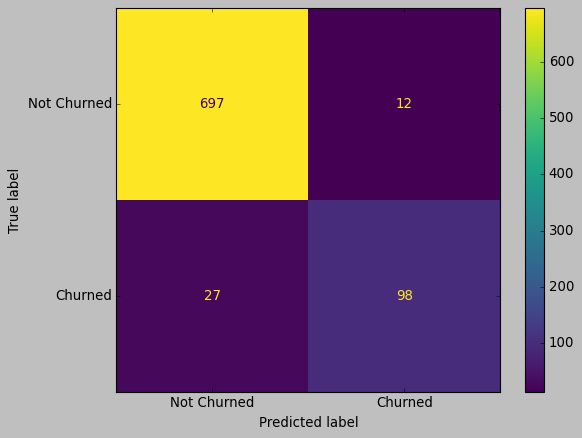

In [84]:
y_pred = final_model.predict(X_test_scaled)
cnf = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cnf)
disp.plot()
disp.ax_.set_xticklabels(['Not Churned', 'Churned'])
disp.ax_.set_yticklabels(['Not Churned', 'Churned'])

plt.savefig('Images/Conf_Matrix_Custom_label.png')
plt.show();

<div class="alert alert-block alert-info">

**Observation:**

So, our `final_model` correctly predicted:
- 98 customers who churned
- 699 customers who did not churn

However, it incorrectly predicted: 
- 10 customers would churn (who did not churn)
- 26 customers would not churn (who did in fact churn)

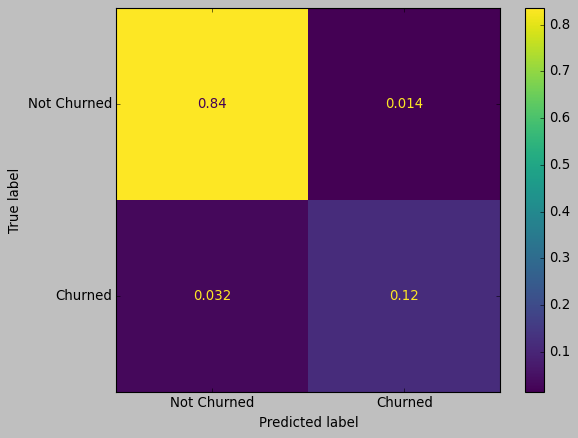

In [90]:
# Again with Normalized results
cnf_norm = confusion_matrix(y_test, y_pred, normalize='all')

disp = ConfusionMatrixDisplay(confusion_matrix=cnf_norm)
disp.plot()
disp.ax_.set_xticklabels(['Not Churned', 'Churned'])
disp.ax_.set_yticklabels(['Not Churned', 'Churned'])

plt.savefig('Images/Conf_Matrix_Custom_Normalized_Final.png')
plt.show();

### `Feature` Significance

With our `final_model` set, we can use this model to identify which Features are most influential in determining the Target, that is: which Features have the highest impact in whether a customer churns or not.

In [91]:
# Creating DataFrame with the Significance of the Features

significance_df = pd.DataFrame(
    {'Features': X_train_scaled.columns, 
     'Significance': final_model.feature_importances_})

# Sorting the DataFrame according to the Significance, in descending order

significance_df = significance_df.sort_values(by='Significance', ascending=False)

In [92]:
plt.style.use('fast')

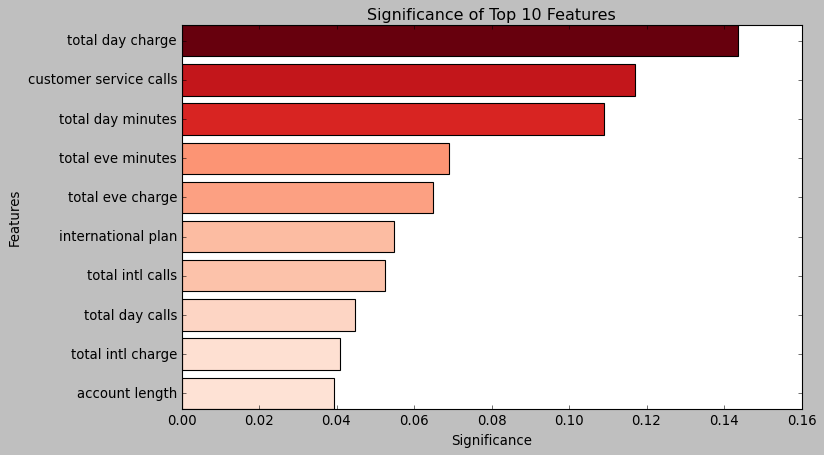

In [95]:
# Plotting the Significance of the Features for comparison in descending order

norm = plt.Normalize(significance_df['Significance'].min(), 
                     significance_df['Significance'].max())

colors = cm.Reds(norm(significance_df['Significance']))

plt.figure(figsize=(10,6))

plt.barh(significance_df['Features'][:10],
         significance_df['Significance'][:10],
         color=colors)
plt.xlabel('Significance')
plt.ylabel('Features')
plt.title('Significance of Top 10 Features')
plt.gca().invert_yaxis()

plt.savefig('Images/Top_10_Features_Final_2.png', bbox_inches='tight')
plt.show();

<div class="alert alert-block alert-info">
    
**Observation:** As we can see from the graph, we have the Top 10 Features in terms of their significance on predicting whether or not a customer will churn. Of these features, the Top 3 stand above the rest in their significance:
    
1. `total day charge`, or the total charge for calls made during the day.
    * The biggest factor is how much customers were charged for calls they made during the day. The reason day calls are more significant than night calls is most likely due to the fact people make most of their calls during the day.
    * **The more they were charged, the more likely they are to churn.**
<br><br>
2. `customer service calls`, or the number of times the customer has called customer service.
    * The second biggest factor in customer churning is the number of times they have reached out to custoemr service. This could be due to the fact that customer service was unable to help them fix their problems, or that customer service is not an easy or reliable experience for customers.
    * **The more a customer calls customer service, the more likely they are to churn.**
      <br><br>  
3. `total day minutes`, or the total minutes spent on calls during the day.
    * This is closely related to `total day charge`, as more minutes spent during calls means a higher charge.
    * **Customers are more likely to churn if they have higher day minutes.**

### Evaluation

# IV. Conclusion

#### False Negatives and Recall
To recap our work, we have analyzed SyriaTel's dataset in order to better understand patterns that indicate a customer may be on the verge of churning. In analyzing these patterns and trying to make informed predictions, we paid special attention to the rates of identifying **False Negatives**, or incorrectly predicting a customer will not churn when in fact they did churn. 

The reason we paid closer attention to False Negatives is because, for our purposes, False Negatives would be far more costly than False Positives: if we mistakenly identify a customer as one who will churn and deploy strategies to keep the customer, it is true that it technically would have been a waste of resources, however even in this case it would only serve to strengthen their loyalty to the company.

On the other hand, if we failed to identify a customer who is on the verge of churning, then we will fail to deploy the strategy to maintain the customer and will lead to the customer churning, a much higher cost to the company than unwisely spending resources on customers who wouldn't have churned.

To minimize our rates of False Negatives, we focused on maximizing the **Recall Score** of our models, which directly reflects the models' abilities to identify False Negatives.

#### Testing and Tuning Models

We initially deployed three models on our training data, each with its own strengths and limitations: Logistic Regression, Random Forest Classifier, and Adaptive Boost Classifier. After finding that the Random Forest Classifier performed best according to our metrics (ie: Recall Score), we tuned the parameters of the model until we found the optimal configuration in maximizing the Recall. 

The `Random Forest Classifier` essentially runs several Decision Trees and uses insight from those Trees to form a final prediction. This classifier is adept at handling potentially non-linear relationships, and for our purposes, is well-suited in determining significance of the Features in making predictions. Though this classifier is susceptible to bias with imbalanced datasets, we were able to mimnimize this impact by utilizing `SMOTE` to over-sample our minority Target class.

#### Feature Significance

Our model helped us identify the top factors that determine customer churn: 
1. Day Calls: how much time a customer spent making calls during the day and, relatedly, how much they were charged for these calls.<br><br>
2. Customer Service Calls: how many times a customer called SyriaTel's customer service number, indicating either that customer service was unable to resolve the customer's issues, or that the experience of contacting customer service was itself unpleasant.

## Limitations

There were a number of factors that hindered our ability to analyze the data and surmise appropriate insights. Some of these confounding factors include:

1. Lack of knowledge around the timing of these customers churning and if they coincided with policy changes at SyriaTel, such as a hike in prices or alterations to family plans.<br><br>
2. It is also difficult to account for policy changes at competing telecom companies, so we're unable to find out if customers churned due to preferable plans or pricing at SyriaTel's competitors.

## Recommendations

With the insights we have gained, we recommend the following:
1. Revisiting our Customer Service protocol, and potentially revamping the entire process so it is more pleasant to the customer and more responsive to their needs.<br><br>
2. Reconsidering charges and plans for day calls, potentially providing a voucher of sorts for customers who call customer service and have high rates of day calls.